### Notebook Purpose: Gated Transformer + Baseline Hybrid
- Implement the gated Transformer hurdle model aligned with the ML baseline
- Reuse window_index and cached grids for strict comparability
- Train classifier/log-volume heads with gating, tune thresholds, evaluate once on test
- Export checkpoints, sweeps, and metrics tables/plots under `results/`

### Note
- Shared inputs/outputs and execution conventions are documented in the project README.


In [ ]:
import sys
from pathlib import Path

from google.colab import drive
drive.mount('/content/drive')

# Minimal environment setup to keep the notebook focused on the core experiments.
# If you run this elsewhere, update PROJECT_DIR accordingly.
PROJECT_DIR = Path("/content/drive/MyDrive/0.Portfolio/electricity_price_forecasting").resolve()


In [ ]:
project_str = str(PROJECT_DIR)
if project_str not in sys.path:
    sys.path.insert(0, project_str)

DATA_DIR         = PROJECT_DIR / "data"
RESULTS_DIR      = PROJECT_DIR / "results"
METRICS_DIR      = RESULTS_DIR / "metrics"
MODELS_DIR       = RESULTS_DIR / "models"
WINDOW_INDEX_DIR = RESULTS_DIR / "window_index"
LOGS_DIR         = RESULTS_DIR / "logs"
CACHE_DIR        = RESULTS_DIR / "cache"
PLOTS_DIR        = RESULTS_DIR / "plots"

for p in [
    RESULTS_DIR,
    PLOTS_DIR,
    METRICS_DIR,
    MODELS_DIR,
    WINDOW_INDEX_DIR,
    LOGS_DIR,
    CACHE_DIR,
    PLOTS_DIR / "models",
    PLOTS_DIR / "eval/curves",
    PLOTS_DIR / "eval/tables",
    PLOTS_DIR / "eda",
    PLOTS_DIR / "feature_engineering",
]:
    p.mkdir(parents=True, exist_ok=True)


# 05 — DL Gated Transformer (Hurdle) vs Baseline (Window-Based)

This notebook follows the **same experimental design** as `03_LGBM_Baseline_hybrid.ipynb`:
- Train: **2021–2023** (parquet), Test: **2024** (parquet)
- **WIN=128**, **HORIZON=10**
- Uses the **same persisted window_index** files *(ID_code, start_pos)* from the LGBM experiment
- Validation is **time-based within train** (last 10% per ID), and **all threshold/model selection is validation-only**
- Test is evaluated **once at the end**

Model:
- **Gated Transformer + two-head hurdle**
  - Head 1: active logits (BCE)
  - Head 2: log1p(volume) regression (masked Huber/MSE on active only)
- Prices (**High/Low/Close**) are kept as **persistence baseline**; the DL model predicts **Volume only**

Artifacts:
- `results/metrics/dl_hurdle_tcn.json`
- threshold sweep curve (PNG)
- baseline vs model bar chart (PNG)
- metrics table (CSV/JSON/PNG)


In [10]:
# === Setup ===
# All code / comments / prints are intentionally written in English.

import json
import math
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler

from IPython.display import display

# -----------------------------
# Reproducibility
# -----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"OK: Torch {torch.__version__} | device={DEVICE} | cuda_available={torch.cuda.is_available()}")

# -----------------------------
# Caps / split (keep aligned with legacy notebooks)
# -----------------------------
MAX_TRAIN_WINDOWS = 300_000
MAX_VAL_WINDOWS = 100_000
VALID_RATIO = 0.1

# -----------------------------
# Shared project imports (must match LGBM notebook)
# -----------------------------
from electricity_forecasting.config import (
    WIN,
    HORIZON,
    MAX_TEST_WINDOWS,
    TARGET_COLS,
    VOLUME_INDEX,
    FREQ,
    BERLIN_TZ,
)

from electricity_forecasting.io.id_mapping import (
    load_id_mapping_json,
    save_id_mapping_json,
    scan_unique_ids_from_parquet,
    build_id_mapping,
)

from electricity_forecasting.preprocessing.grid_single_id import (
    load_one_id_observed,
    build_15min_grid_single_id,
)
from electricity_forecasting.preprocessing.features import (
    add_time_features,
    add_lag_features,
    add_rolling_features,
)
from electricity_forecasting.datasets.materialize import infer_feature_cols  # reuse ML feature list heuristic

from electricity_forecasting.evaluation.evaluate import (
    load_window_index,
    hash_window_index,
    evaluate_predictions,
    active_ratio_from_truth,
    build_metrics_record,
    save_json,
)
from electricity_forecasting.evaluation.reporting import (
    make_metrics_table,
    save_metrics_table,
    save_metrics_table_figure,
)
from electricity_forecasting.viz.plots import plot_and_save_baseline_vs_model_bar
from electricity_forecasting.evaluation.metrics import smape_flat

# Ensure output folders exist (idempotent)
(RESULTS_DIR / "cache" / "grids").mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("OK: Setup complete.")
print(
    "Constants:",
    {
        "WIN": WIN,
        "HORIZON": HORIZON,
        "MAX_TEST_WINDOWS": MAX_TEST_WINDOWS,
        "MAX_TRAIN_WINDOWS": MAX_TRAIN_WINDOWS,
        "MAX_VAL_WINDOWS": MAX_VAL_WINDOWS,
        "VALID_RATIO": VALID_RATIO,
        "FREQ": FREQ,
        "TARGET_COLS": list(TARGET_COLS),
        "VOLUME_INDEX": int(VOLUME_INDEX),
        "MODEL_SLUG": MODEL_SLUG,
    },
)


OK: Torch 2.9.0+cu126 | device=cuda | cuda_available=True
OK: Setup complete.
Constants: {'WIN': 128, 'HORIZON': 10, 'MAX_TEST_WINDOWS': 200000, 'MAX_TRAIN_WINDOWS': 300000, 'MAX_VAL_WINDOWS': 100000, 'VALID_RATIO': 0.1, 'FREQ': '15min', 'TARGET_COLS': ['high', 'low', 'close', 'volume'], 'VOLUME_INDEX': 3, 'MODEL_SLUG': 'dl_gated_transformer_hurdle'}


In [3]:
# === Load window_index (must be identical to LGBM experiment) ===

TRAIN_PARQUET = DATA_DIR / "TRAIN_Reco_2021_2022_2023_with_time_utc.parquet"
TEST_PARQUET  = DATA_DIR / "TEST_Reco_2024_with_time_utc.parquet"

if not TRAIN_PARQUET.exists():
    raise FileNotFoundError("Train parquet not found under DATA_DIR: TRAIN_Reco_2021_2022_2023_with_time_utc.parquet")
if not TEST_PARQUET.exists():
    raise FileNotFoundError("Test parquet not found under DATA_DIR: TEST_Reco_2024_with_time_utc.parquet")

# Time bounds used to build per-ID 15-min grids (must match legacy notebooks)
TRAIN_START = pd.Timestamp("2021-01-01 00:00:00", tz="UTC")
TRAIN_END   = pd.Timestamp("2023-12-31 23:45:00", tz="UTC")
TEST_START  = pd.Timestamp("2024-01-01 00:00:00", tz="UTC")
TEST_END    = pd.Timestamp("2024-12-31 23:45:00", tz="UTC")

# ID mapping cache: raw string -> code int (must match LGBM notebook)
ID_MAP_PATH = RESULTS_DIR / "window_index" / "id_code_mapping.json"
if ID_MAP_PATH.exists():
    ID_TO_CODE, CODE_TO_ID, ALL_CODES = load_id_mapping_json(ID_MAP_PATH)
    print(f"OK: Loaded cached ID mapping | n_ids={len(ALL_CODES)}")
else:
    t0 = time.time()
    ids_raw = scan_unique_ids_from_parquet(str(TEST_PARQUET), id_col="ID")
    ID_TO_CODE, CODE_TO_ID, ALL_CODES = build_id_mapping(ids_raw)
    save_id_mapping_json(ID_MAP_PATH, id_to_code=ID_TO_CODE, code_to_id=CODE_TO_ID)
    print(f"OK: Built + saved ID mapping | n_ids={len(ALL_CODES)} | sec={(time.time()-t0):.1f}")

def resolve_window_index_path(preferred: Path) -> Path:
    """
    LGBM notebook saves under results/window_index/.
    If your files live directly under results/, we fallback automatically.
    """
    if preferred.exists():
        return preferred

    alt = preferred.parent.parent / preferred.name  # results/<file>
    if alt.exists():
        print("WARN: Using window_index file from results/:", alt.name)
        return alt

    # Last resort: recursive search (bounded to results/)
    matches = list((preferred.parent.parent).rglob(preferred.name))
    if len(matches) > 0:
        print("WARN: Using window_index file from recursive search:", matches[0].name)
        return matches[0]

    raise FileNotFoundError(
        f"window_index file not found: {preferred.name}. "
        "Run the LGBM notebook first to generate window_index files under results/window_index/."
    )

# Load window_index CSVs created by LGBM experiment
p_tr = resolve_window_index_path(RESULTS_DIR / "window_index" / f"train_windows_all_ids_cap{MAX_TRAIN_WINDOWS}.csv")
p_va = resolve_window_index_path(RESULTS_DIR / "window_index" / f"val_windows_all_ids_cap{MAX_VAL_WINDOWS}.csv")
p_te = resolve_window_index_path(RESULTS_DIR / "window_index" / f"test_windows_all_ids_cap{MAX_TEST_WINDOWS}.csv")

w_tr = load_window_index(p_tr)
w_va = load_window_index(p_va)
w_te = load_window_index(p_te)

print("Window counts:", {"train": len(w_tr), "val": len(w_va), "test": len(w_te)})
print(
    "Unique ID codes:",
    {"train": int(w_tr["ID"].nunique()), "val": int(w_va["ID"].nunique()), "test": int(w_te["ID"].nunique())},
)
print("Hashes:", {"train": hash_window_index(w_tr), "val": hash_window_index(w_va), "test": hash_window_index(w_te)})

# IDs actually used (keeps downstream preprocessing bounded)
USED_ID_CODES = sorted(set(w_tr["ID"].unique().tolist()) | set(w_va["ID"].unique().tolist()) | set(w_te["ID"].unique().tolist()))
print("IDs used across train/val/test:", len(USED_ID_CODES))
print("Example ID codes:", USED_ID_CODES[:10])


OK: Loaded cached ID mapping | n_ids=672
Window counts: {'train': 300000, 'val': 100000, 'test': 200000}
Unique ID codes: {'train': 672, 'val': 672, 'test': 672}
Hashes: {'train': 'f68a7c486e7eb04928a78280e905ac1d086315728d1e6cac40816b39b13159c6', 'val': 'c376472b202091885e46781ed4bcfadf8fcbf1f2f95c1a5c1c89f39e7b2cb7d9', 'test': '005f0255eeb9af52c6b63faa2f9cef3d63bc38277714b20e74151379f241a391'}
IDs used across train/val/test: 672
Example ID codes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [4]:
# === Dataset materialization (streaming, window_index-driven) ===
# We avoid building a gigantic multi-ID grid. Instead, we build per-ID grids on demand and cache them on disk.

CACHE_GRIDS = True
CACHE_DIR_TRAIN = RESULTS_DIR / "cache/grids/train_2021_2023"
CACHE_DIR_TEST  = RESULTS_DIR / "cache/grids/test_2024"
CACHE_DIR_TRAIN.mkdir(parents=True, exist_ok=True)
CACHE_DIR_TEST.mkdir(parents=True, exist_ok=True)

def build_one_id_grid_with_features(
    parquet_path: Path,
    id_code: int,
    start_utc: pd.Timestamp,
    end_utc: pd.Timestamp,
) -> pd.DataFrame:
    # Robust single-ID grid builder (15-min snap + deduplicate + ffill/bfill)
    raw_id = CODE_TO_ID[int(id_code)]

    df_obs = load_one_id_observed(
        parquet_path=str(parquet_path),
        raw_id=str(raw_id),
        start_utc=start_utc,
        end_utc=end_utc,
    )
    df_grid = build_15min_grid_single_id(
        df_obs=df_obs,
        raw_id=str(raw_id),
        start_utc=start_utc,
        end_utc=end_utc,
        freq=FREQ,
        price_cols=("high", "low", "close"),
        volume_col="volume",
    )

    # Use integer code for downstream indexing
    df_grid["ID"] = int(id_code)

    # Feature engineering (same primitives as the ML notebook)
    df_grid["logvol"] = np.log1p(df_grid["volume"].astype(np.float32))

    df_grid = add_time_features(
        df_grid,
        tz=BERLIN_TZ,
        time_col="ExecutionTime",
        id_col="ID",
        prefix="berlin",
        add_cyclical=True,
    )
    df_grid = add_lag_features(df_grid, cols=("logvol",), lags=(1, 2), id_col="ID", time_col="ExecutionTime")
    df_grid = add_rolling_features(df_grid, cols=("logvol",), windows=(4, 16), shift=1, id_col="ID", time_col="ExecutionTime")

    return df_grid

# Determine FEATURE_COLS deterministically (reuse ML heuristic)
sample_id = USED_ID_CODES[0]
df_sample = build_one_id_grid_with_features(TRAIN_PARQUET, sample_id, TRAIN_START, TRAIN_END)
FEATURE_COLS = infer_feature_cols(df_sample)
print("FEATURE_COLS (order fixed):", FEATURE_COLS)
print("n_features:", len(FEATURE_COLS))

def _load_or_build_npz(
    cache_dir: Path,
    parquet_path: Path,
    id_code: int,
    start_utc: pd.Timestamp,
    end_utc: pd.Timestamp,
) -> tuple[np.ndarray, np.ndarray]:
    # Returns:
    #   feat: (T, F)
    #   tgt : (T, C)
    cache_path = cache_dir / f"id_{int(id_code)}.npz"

    if CACHE_GRIDS and cache_path.exists():
        obj = np.load(cache_path)
        feat = obj["feat"].astype(np.float32, copy=False)
        tgt  = obj["tgt"].astype(np.float32, copy=False)
        return feat, tgt

    df = build_one_id_grid_with_features(parquet_path, id_code, start_utc, end_utc)

    # Ensure NaN-free targets
    for c in TARGET_COLS:
        if df[c].isna().any():
            raise ValueError(f"NaNs found in target col '{c}' for ID={id_code}. Grid builder must prevent NaNs.")

    # Ensure NaN-free features
    for c in FEATURE_COLS:
        df[c] = df[c].replace([np.inf, -np.inf], np.nan).fillna(0.0).astype(np.float32)

    feat = df[FEATURE_COLS].to_numpy(dtype=np.float32, copy=False)
    tgt  = df[list(TARGET_COLS)].to_numpy(dtype=np.float32, copy=False)

    if CACHE_GRIDS:
        np.savez(cache_path, feat=feat, tgt=tgt)

    return feat, tgt

class GridCache:
    # Per-split grid cache that stores per-ID arrays on disk (npz).
    def __init__(self, cache_dir: Path, parquet_path: Path, start_utc: pd.Timestamp, end_utc: pd.Timestamp):
        self.cache_dir = Path(cache_dir)
        self.parquet_path = Path(parquet_path)
        self.start_utc = start_utc
        self.end_utc = end_utc

        self._last_id = None
        self._last_feat = None
        self._last_tgt = None

    def get(self, id_code: int) -> tuple[np.ndarray, np.ndarray]:
        id_code = int(id_code)
        if self._last_id == id_code and self._last_feat is not None and self._last_tgt is not None:
            return self._last_feat, self._last_tgt

        feat, tgt = _load_or_build_npz(self.cache_dir, self.parquet_path, id_code, self.start_utc, self.end_utc)

        self._last_id = id_code
        self._last_feat = feat
        self._last_tgt = tgt
        return feat, tgt

train_cache = GridCache(CACHE_DIR_TRAIN, TRAIN_PARQUET, TRAIN_START, TRAIN_END)
test_cache  = GridCache(CACHE_DIR_TEST,  TEST_PARQUET,  TEST_START,  TEST_END)

class WindowSeqDataset(Dataset):
    # Map-style dataset aligned to the canonical window definition.
    #
    # Returns:
    #   x_seq : (WIN, F)
    #   id_code: ()
    #   y_true: (HORIZON, C)
    #   y_base: (HORIZON, C)  persistence baseline aligned to window end
    def __init__(self, window_index: pd.DataFrame, cache: GridCache):
        self.wi = window_index[["ID", "start_pos"]].copy().sort_values(["ID", "start_pos"]).reset_index(drop=True)
        self.cache = cache
        self.ids = self.wi["ID"].to_numpy(dtype=np.int64, copy=False)
        self.spos = self.wi["start_pos"].to_numpy(dtype=np.int64, copy=False)

    def __len__(self) -> int:
        return int(len(self.wi))

    def __getitem__(self, idx: int):
        id_code = int(self.ids[idx])
        start_pos = int(self.spos[idx])

        feat, tgt = self.cache.get(id_code)  # feat (T,F), tgt (T,C)
        T = int(tgt.shape[0])

        max_start = T - WIN - HORIZON
        if start_pos < 0 or start_pos > max_start:
            raise ValueError(f"Invalid start_pos={start_pos} for ID={id_code} (allowed 0..{max_start})")

        x = feat[start_pos : start_pos + WIN, :]  # (WIN,F)
        y = tgt[start_pos + WIN : start_pos + WIN + HORIZON, :]  # (H,C)
        last = tgt[start_pos + WIN - 1, :]  # (C,)
        y_base = np.repeat(last.reshape(1, -1), repeats=HORIZON, axis=0).astype(np.float32)

        x_t = torch.from_numpy(np.asarray(x, dtype=np.float32))
        y_t = torch.from_numpy(np.asarray(y, dtype=np.float32))
        yb_t = torch.from_numpy(np.asarray(y_base, dtype=np.float32))
        id_t = torch.tensor(id_code, dtype=torch.long)

        return x_t, id_t, y_t, yb_t

# DataLoaders
use_pin = (DEVICE.type == "cuda")
NUM_WORKERS = 0

TRAIN_BATCH = 1024 if DEVICE.type == "cuda" else 256
EVAL_BATCH  = 2048 if DEVICE.type == "cuda" else 512

train_ds = WindowSeqDataset(w_tr, train_cache)
val_ds   = WindowSeqDataset(w_va, train_cache)
test_ds  = WindowSeqDataset(w_te, test_cache)

train_loader = DataLoader(train_ds, batch_size=TRAIN_BATCH, shuffle=False, num_workers=NUM_WORKERS, pin_memory=use_pin)
val_loader   = DataLoader(val_ds,   batch_size=EVAL_BATCH,  shuffle=False, num_workers=NUM_WORKERS, pin_memory=use_pin)
test_loader  = DataLoader(test_ds,  batch_size=EVAL_BATCH,  shuffle=False, num_workers=NUM_WORKERS, pin_memory=use_pin)

# Sanity check
x0, id0, y0, yb0 = train_ds[0]
print("Sanity shapes:", {"x": tuple(x0.shape), "id": int(id0), "y_true": tuple(y0.shape), "y_base": tuple(yb0.shape)})
print("Dataset sizes:", {"train": len(train_ds), "val": len(val_ds), "test": len(test_ds)})

FEATURE_COLS (order fixed): ['logvol', 'logvol_lag1', 'logvol_lag2', 'logvol_rollmean_16', 'logvol_rollmean_4', 'close', 'high', 'low', 'dow_berlin', 'hour_berlin', 'hour_berlin_cos', 'hour_berlin_sin', 'month_berlin']
n_features: 13
Sanity shapes: {'x': (128, 13), 'id': 0, 'y_true': (10, 4), 'y_base': (10, 4)}
Dataset sizes: {'train': 300000, 'val': 100000, 'test': 200000}


Training started...
Epoch 01 | train loss=0.8753 (bce=0.3806, reg=0.4948) | val loss=1.2968 | time=23.7s
  -> Saved best checkpoint: dl_gated_transformer_hurdle_best.pt
Epoch 02 | train loss=0.8486 (bce=0.3279, reg=0.5206) | val loss=1.2316 | time=24.0s
  -> Saved best checkpoint: dl_gated_transformer_hurdle_best.pt
Epoch 03 | train loss=0.8423 (bce=0.3180, reg=0.5244) | val loss=1.0971 | time=23.7s
  -> Saved best checkpoint: dl_gated_transformer_hurdle_best.pt
Epoch 04 | train loss=0.8350 (bce=0.3253, reg=0.5096) | val loss=1.0611 | time=24.0s
  -> Saved best checkpoint: dl_gated_transformer_hurdle_best.pt
Epoch 05 | train loss=0.8313 (bce=0.3248, reg=0.5065) | val loss=1.0770 | time=24.2s
Epoch 06 | train loss=0.8163 (bce=0.3148, reg=0.5014) | val loss=0.9825 | time=23.7s
  -> Saved best checkpoint: dl_gated_transformer_hurdle_best.pt
Epoch 07 | train loss=0.7981 (bce=0.3147, reg=0.4834) | val loss=1.1207 | time=23.8s
Epoch 08 | train loss=0.7946 (bce=0.3061, reg=0.4885) | val loss=

,epoch,train_loss,train_bce,train_reg,train_time_sec,val_loss,val_bce,val_reg,val_time_sec
15,16,0.632018,0.295649,0.336369,23.630282,0.819723,0.398746,0.420976,14.377890
16,17,0.615946,0.289157,0.326788,23.596950,0.827312,0.442928,0.384384,14.608220
17,18,0.616219,0.288323,0.327896,23.846773,0.797769,0.412033,0.385735,14.397529
18,19,0.606971,0.289758,0.317213,23.976495,0.772253,0.426734,0.345519,14.171436
19,20,0.597524,0.276296,0.321228,23.765590,0.820659,0.424033,0.396626,14.216887


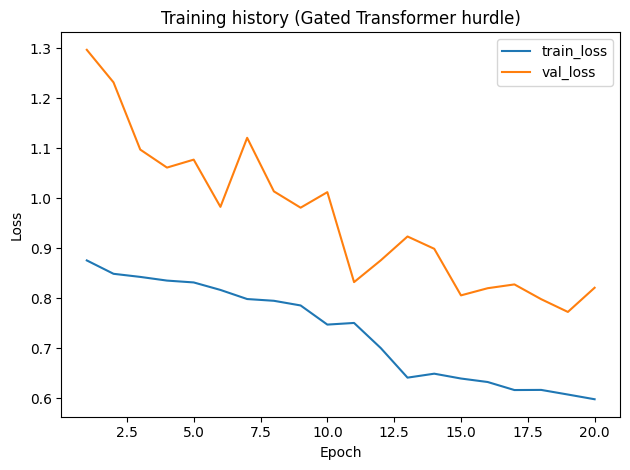

In [8]:
# === Model train (Gated Transformer hurdle) ===

class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 2048):
        super().__init__()
        pe = torch.zeros(max_len, d_model, dtype=torch.float32)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float32) * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0), persistent=False)  # (1, max_len, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        T = x.size(1)
        return x + self.pe[:, :T, :]


class REALGatedEncoderLayer(nn.Module):
    # A lightweight gated residual Transformer encoder layer:
    #   x <- LN( x + sigmoid(g(x)) * Attn(x) )
    #   x <- LN( x + sigmoid(h(x)) * FF(x) )
    def __init__(self, d_model: int, nhead: int, dim_ff: int, dropout: float):
        super().__init__()
        self.mha = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.ln1 = nn.LayerNorm(d_model)

        self.ff1 = nn.Linear(d_model, dim_ff)
        self.ff2 = nn.Linear(dim_ff, d_model)
        self.act = nn.GELU()
        self.ln2 = nn.LayerNorm(d_model)

        self.gate_attn = nn.Linear(d_model, d_model)
        self.gate_ff = nn.Linear(d_model, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        attn_out, _ = self.mha(x, x, x, need_weights=False)
        gate1 = torch.sigmoid(self.gate_attn(x))
        x = self.ln1(x + self.dropout(gate1 * attn_out))

        ff = self.ff2(self.dropout(self.act(self.ff1(x))))
        gate2 = torch.sigmoid(self.gate_ff(x))
        x = self.ln2(x + self.dropout(gate2 * ff))
        return x


class GatedTransformerHurdle(nn.Module):
    def __init__(
        self,
        n_features: int,
        n_ids: int,
        horizon: int,
        d_model: int = 64,
        nhead: int = 4,
        n_layers: int = 2,
        dim_ff: int = 128,
        dropout: float = 0.10,
        id_emb_dim: int = 8,
        max_len: int = 256,
    ):
        super().__init__()
        self.in_proj = nn.Linear(n_features, d_model)
        self.pos = SinusoidalPositionalEncoding(d_model=d_model, max_len=max_len)

        self.layers = nn.ModuleList(
            [REALGatedEncoderLayer(d_model=d_model, nhead=nhead, dim_ff=dim_ff, dropout=dropout) for _ in range(n_layers)]
        )

        self.id_emb = nn.Embedding(n_ids, id_emb_dim)

        self.head = nn.Sequential(
            nn.Linear(d_model + id_emb_dim, d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        self.active_out = nn.Linear(d_model, horizon)   # logits
        self.logvol_out = nn.Linear(d_model, horizon)   # regression (log1p volume)

    def forward(self, x_seq: torch.Tensor, id_code: torch.Tensor):
        # x_seq: (B, WIN, F)
        x = self.in_proj(x_seq)          # (B, WIN, d_model)
        x = self.pos(x)

        for layer in self.layers:
            x = layer(x)

        h = x[:, -1, :]                  # last token
        emb = self.id_emb(id_code)       # (B, id_emb_dim)

        z = torch.cat([h, emb], dim=-1)
        z = self.head(z)

        active_logits = self.active_out(z)   # (B, H)
        logvol_hat = self.logvol_out(z)      # (B, H)
        return active_logits, logvol_hat


def hurdle_loss(
    active_logits: torch.Tensor,
    logvol_hat: torch.Tensor,
    y_true: torch.Tensor,
    *,
    volume_index: int,
    pos_weight: float | None = None,
    reg_loss: str = "huber",
    huber_delta: float = 1.0,
    lambda_reg: float = 1.0,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    # y_true: (B, H, C) in original scale
    y_vol = y_true[:, :, volume_index].clamp(min=0.0)
    y_active = (y_vol > 0.0).float()
    y_logvol = torch.log1p(y_vol)

    if pos_weight is not None:
        pw = torch.tensor(float(pos_weight), device=active_logits.device)
        bce = F.binary_cross_entropy_with_logits(active_logits, y_active, pos_weight=pw, reduction="mean")
    else:
        bce = F.binary_cross_entropy_with_logits(active_logits, y_active, reduction="mean")

    if reg_loss.lower() == "mse":
        reg_elem = F.mse_loss(logvol_hat, y_logvol, reduction="none")
    else:
        reg_elem = F.huber_loss(logvol_hat, y_logvol, delta=huber_delta, reduction="none")

    mask = y_active
    denom = mask.sum().clamp(min=1.0)
    reg = (reg_elem * mask).sum() / denom

    total = bce + float(lambda_reg) * reg
    return total, bce, reg


# Hyperparameters (keep modest so CPU runs are still feasible)
D_MODEL = 64
NHEAD = 4
N_LAYERS = 2
DIM_FF = 128
DROPOUT = 0.10
ID_EMB_DIM = 8

LR = 2e-3
WEIGHT_DECAY = 1e-4
EPOCHS = 20
PATIENCE = 5
GRAD_CLIP = 1.0

POS_WEIGHT = 12.0  # ~ (1 - active_ratio) / active_ratio; fixed for reproducibility
LAMBDA_REG = 1.0
REG_LOSS = "huber"

model = GatedTransformerHurdle(
    n_features=len(FEATURE_COLS),
    n_ids=len(ALL_CODES),
    horizon=HORIZON,
    d_model=D_MODEL,
    nhead=NHEAD,
    n_layers=N_LAYERS,
    dim_ff=DIM_FF,
    dropout=DROPOUT,
    id_emb_dim=ID_EMB_DIM,
    max_len=max(WIN, 256),
).to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

use_amp = (DEVICE.type == "cuda")
scaler = GradScaler("cuda", enabled=use_amp)

ckpt_path = RESULTS_DIR / "models" / f"{MODEL_SLUG}_best.pt"

def run_epoch(model, loader, train: bool):
    model.train(train)

    losses, bces, regs = [], [], []
    t0 = time.time()

    for x, idc, y_true, _y_base in loader:
        x = x.to(DEVICE, non_blocking=True)
        idc = idc.to(DEVICE, non_blocking=True)
        y_true = y_true.to(DEVICE, non_blocking=True)

        if train:
            optimizer.zero_grad(set_to_none=True)

        with autocast("cuda", enabled=use_amp):
            active_logits, logvol_hat = model(x, idc)
            loss, bce, reg = hurdle_loss(
                active_logits, logvol_hat, y_true,
                volume_index=VOLUME_INDEX,
                pos_weight=POS_WEIGHT,
                reg_loss=REG_LOSS,
                lambda_reg=LAMBDA_REG,
            )

        if train:
            scaler.scale(loss).backward()
            if GRAD_CLIP is not None:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), float(GRAD_CLIP))
            scaler.step(optimizer)
            scaler.update()

        losses.append(loss.detach().item())
        bces.append(bce.detach().item())
        regs.append(reg.detach().item())

    return {
        "loss": float(np.mean(losses)),
        "bce": float(np.mean(bces)),
        "reg": float(np.mean(regs)),
        "time_sec": float(time.time() - t0),
    }

best_val = float("inf")
best_epoch = -1
no_improve = 0
history = []

print("Training started...")
for epoch in range(1, EPOCHS + 1):
    tr = run_epoch(model, train_loader, train=True)
    va = run_epoch(model, val_loader, train=False)

    row = {"epoch": epoch, **{f"train_{k}": v for k, v in tr.items()}, **{f"val_{k}": v for k, v in va.items()}}
    history.append(row)

    print(
        f"Epoch {epoch:02d} | "
        f"train loss={tr['loss']:.4f} (bce={tr['bce']:.4f}, reg={tr['reg']:.4f}) | "
        f"val loss={va['loss']:.4f} | "
        f"time={tr['time_sec']:.1f}s"
    )

    if va["loss"] < best_val - 1e-4:
        best_val = va["loss"]
        best_epoch = epoch
        no_improve = 0
        torch.save({"model": model.state_dict(), "epoch": epoch, "val_loss": best_val}, ckpt_path)
        print("  -> Saved best checkpoint:", ckpt_path.name)
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f"Early stopping: no improvement for {PATIENCE} epochs.")
            break

ckpt = torch.load(ckpt_path, map_location=DEVICE)
model.load_state_dict(ckpt["model"])
print("OK: Loaded best checkpoint:", {"epoch": ckpt.get("epoch"), "val_loss": ckpt.get("val_loss")})

hist_df = pd.DataFrame(history)
display(hist_df.tail())

# Plot training curves
plt.figure()
plt.plot(hist_df["epoch"], hist_df["train_loss"], label="train_loss")
plt.plot(hist_df["epoch"], hist_df["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training history (Gated Transformer hurdle)")
plt.legend()
plt.tight_layout()
plt.show()

OK: Validation inference done: {'proba': (100000, 10), 'logvol_hat': (100000, 10), 'y_vol': (100000, 10), 'sec': '14.9'}
Best threshold (selected on validation): 0.9
Best validation volume FULL sMAPE: 0.1090958473321176


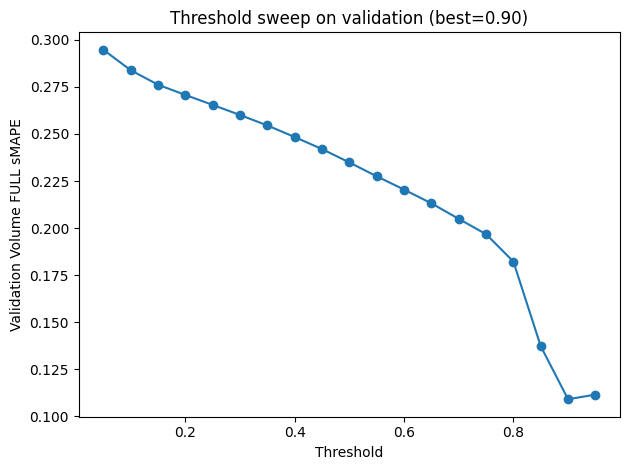

Saved: dl_gated_transformer_hurdle_threshold_sweep_volume_full.png


In [12]:
# === Validation threshold sweep (validation-only selection) ===

@torch.no_grad()
def predict_heads_and_truth(loader):
    model.eval()
    proba_list, logvol_list, yvol_list = [], [], []

    for x, idc, y_true, _y_base in loader:
        x = x.to(DEVICE, non_blocking=True)
        idc = idc.to(DEVICE, non_blocking=True)
        y_true = y_true.to(DEVICE, non_blocking=True)

        active_logits, logvol_hat = model(x, idc)
        proba = torch.sigmoid(active_logits)

        y_vol = y_true[:, :, VOLUME_INDEX].clamp(min=0.0)

        proba_list.append(proba.detach().cpu().numpy().astype(np.float32))
        logvol_list.append(logvol_hat.detach().cpu().numpy().astype(np.float32))
        yvol_list.append(y_vol.detach().cpu().numpy().astype(np.float32))

    return (
        np.concatenate(proba_list, axis=0),
        np.concatenate(logvol_list, axis=0),
        np.concatenate(yvol_list, axis=0),
    )

t0 = time.time()
proba_va, logvol_hat_va, yvol_va = predict_heads_and_truth(val_loader)
print("OK: Validation inference done:", {"proba": proba_va.shape, "logvol_hat": logvol_hat_va.shape, "y_vol": yvol_va.shape, "sec": f"{time.time()-t0:.1f}"})

def apply_hurdle(proba: np.ndarray, logvol_hat: np.ndarray, thr: float) -> np.ndarray:
    vol = np.expm1(logvol_hat.astype(np.float64))
    vol = np.clip(vol, 0.0, None)
    gate = (proba.astype(np.float64) >= float(thr)).astype(np.float64)
    return (gate * vol).astype(np.float32)

thr_grid = np.linspace(0.05, 0.95, 19)
scores = []
y_true_flat = yvol_va.reshape(-1)

for thr in thr_grid:
    y_pred_flat = apply_hurdle(proba_va, logvol_hat_va, thr).reshape(-1)
    scores.append(smape_flat(y_true_flat, y_pred_flat))

scores = np.array(scores, dtype=np.float64)
best_idx = int(np.nanargmin(scores))
best_thr = float(thr_grid[best_idx])
best_score = float(scores[best_idx])

print("Best threshold (selected on validation):", best_thr)
print("Best validation volume FULL sMAPE:", best_score)

# Plot sweep
sweep_df = pd.DataFrame({"threshold": thr_grid, "val_volume_full_smape": scores})
curve_path = PLOTS_DIR / "eval" / "curves" / f"{MODEL_SLUG}_threshold_sweep_volume_full.png"

plt.figure()
plt.plot(sweep_df["threshold"], sweep_df["val_volume_full_smape"], marker="o")
plt.xlabel("Threshold")
plt.ylabel("Validation Volume FULL sMAPE")
plt.title(f"Threshold sweep on validation (best={best_thr:.2f})")
plt.tight_layout()
plt.savefig(curve_path, dpi=160)
plt.show()

print("Saved:", curve_path.name)

threshold_info = {
    "threshold_grid": [float(x) for x in thr_grid.tolist()],
    "val_volume_full_smape_curve": [float(x) for x in scores.tolist()],
    "threshold_selected": float(best_thr),
    "threshold_selected_on": "validation",
    "metric_optimized": "volume_full_smape_on_validation",
}

In [15]:
# === Test evaluation (single run at the end) ===

@torch.no_grad()
def predict_on_test(loader, thr: float):
    model.eval()
    Y_true_list = []
    Y_base_list = []
    Y_pred_model_list = []

    for x, idc, y_true, y_base in loader:
        x = x.to(DEVICE, non_blocking=True)
        idc = idc.to(DEVICE, non_blocking=True)

        active_logits, logvol_hat = model(x, idc)
        proba = torch.sigmoid(active_logits)

        vol = torch.expm1(logvol_hat).clamp(min=0.0)
        gate = (proba >= float(thr)).float()
        vol_hat = gate * vol  # (B,H)

        y_pred = y_base.clone()
        y_pred[:, :, VOLUME_INDEX] = vol_hat.cpu()

        Y_true_list.append(y_true.numpy().astype(np.float32, copy=False))
        Y_base_list.append(y_base.numpy().astype(np.float32, copy=False))
        Y_pred_model_list.append(y_pred.numpy().astype(np.float32, copy=False))

    Y_true = np.concatenate(Y_true_list, axis=0)
    Y_base = np.concatenate(Y_base_list, axis=0)
    Y_pred_model = np.concatenate(Y_pred_model_list, axis=0)
    return Y_true, Y_base, Y_pred_model

t0 = time.time()
Y_te, Yb_te, Yp_te = predict_on_test(test_loader, best_thr)
print("OK: Test inference done:", {"Y_true": Y_te.shape, "Y_base": Yb_te.shape, "Y_pred_model": Yp_te.shape, "sec": f"{time.time()-t0:.1f}"})

# Canonical metrics (flatten-based Full/Active, active mask from ground-truth volume)
baseline_metrics = evaluate_predictions(Y_true=Y_te, Y_pred=Yb_te, volume_index=VOLUME_INDEX)
model_metrics    = evaluate_predictions(Y_true=Y_te, Y_pred=Yp_te, volume_index=VOLUME_INDEX)

print("Baseline metrics:", baseline_metrics)
print("Model metrics   :", model_metrics)

# Bar chart (baseline vs model)
metrics_bar = {
    "baseline_full": float(baseline_metrics["full_smape"]),
    "baseline_active": float(baseline_metrics["active_smape"]),
    "model_full": float(model_metrics["full_smape"]),
    "model_active": float(model_metrics["active_smape"]),
}
bar_path = MODEL_DIR / "baseline_vs_model_full_active.png"

plot_and_save_baseline_vs_model_bar(
    metrics_bar=metrics_bar,
    out_png=str(bar_path),
    title="DL Gated Transformer (Volume only) vs Baseline (canonical metrics)",
    dpi=160,
)
print("Saved:", _safe_rel(bar_path))

In [16]:
# === Save artifacts (plots + tables + json) ===

record = build_metrics_record(
    model_name=MODEL_SLUG,
    run_tag="dl_gated_transformer_window_based",
    constants={
        "WIN": WIN,
        "HORIZON": HORIZON,
        "MAX_TEST_WINDOWS": MAX_TEST_WINDOWS,
        "MAX_TRAIN_WINDOWS": MAX_TRAIN_WINDOWS,
        "MAX_VAL_WINDOWS": MAX_VAL_WINDOWS,
        "TARGET_COLS": list(TARGET_COLS),
        "VOLUME_INDEX": int(VOLUME_INDEX),
        "FREQ": FREQ,
        "FEATURE_COLS": list(FEATURE_COLS),
        "seed": int(SEED),
    },
    split_info={
        "valid_ratio": float(VALID_RATIO),
        "threshold_selected_on": "validation",
        "time_bounds": {
            "train_start_utc": str(TRAIN_START),
            "train_end_utc": str(TRAIN_END),
            "test_start_utc": str(TEST_START),
            "test_end_utc": str(TEST_END),
        },
    },
    sampling_info={
        "n_ids_train": int(w_tr["ID"].nunique()),
        "n_ids_val": int(w_va["ID"].nunique()),
        "n_ids_test": int(w_te["ID"].nunique()),
        "n_train_windows_used": int(len(w_tr)),
        "n_val_windows_used": int(len(w_va)),
        "n_test_windows_used": int(len(w_te)),
        "window_index_paths": {"train": str(p_tr), "val": str(p_va), "test": str(p_te)},
        "window_index_hashes": {"train": hash_window_index(w_tr), "val": hash_window_index(w_va), "test": hash_window_index(w_te)},
        "test_window_sampling_rule": "ID-balanced + spread start_pos + global cap",
    },
    baseline_metrics=baseline_metrics,
    model_metrics=model_metrics,
    active_ratio_test=active_ratio_from_truth(Y_te, volume_index=VOLUME_INDEX),
    threshold_info=threshold_info,
    extra={
        "torch_version": torch.__version__,
        "device": str(DEVICE),
        "arch": "Gated Transformer + two-head hurdle (BCE + masked Huber on log1p(volume))",
        "d_model": int(D_MODEL),
        "nhead": int(NHEAD),
        "n_layers": int(N_LAYERS),
        "dim_ff": int(DIM_FF),
        "dropout": float(DROPOUT),
        "id_emb_dim": int(ID_EMB_DIM),
        "lr": float(LR),
        "weight_decay": float(WEIGHT_DECAY),
        "epochs_ran": int(len(history)),
        "best_epoch": int(best_epoch),
        "pos_weight": float(POS_WEIGHT) if POS_WEIGHT is not None else None,
        "lambda_reg": float(LAMBDA_REG),
        "reg_loss": str(REG_LOSS),
        "cache_grids": bool(CACHE_GRIDS),
    },
)

out_json = RESULTS_DIR / "metrics" / f"{MODEL_SLUG}.json"
save_json(record, out_json)
print("Saved metrics JSON:", _safe_rel(out_json))

# Metrics table (per-target Full/Active) + save CSV/JSON/PNG
preds = {
    "1. Baseline (Persistence)": Yb_te,
    "2. DL Gated Transformer (Volume only)": Yp_te,
}

df_tbl = make_metrics_table(
    Y_true=Y_te,
    preds=preds,
    target_cols=list(TARGET_COLS),
    volume_index=VOLUME_INDEX,
    total_mode="mean",
)

display(df_tbl)

tbl_csv = RESULTS_DIR / "metrics" / f"metrics_table_{MODEL_SLUG}_vs_baseline.csv"
tbl_json = RESULTS_DIR / "metrics" / f"metrics_table_{MODEL_SLUG}_vs_baseline.json"
tbl_png = PLOTS_DIR / "eval" / "tables" / f"metrics_table_{MODEL_SLUG}_vs_baseline.png"

save_metrics_table(df_tbl, tbl_csv, tbl_json)
save_metrics_table_figure(df_tbl, tbl_png, title="DL Gated Transformer vs Baseline (Full/Active sMAPE)")

print("Saved:", _safe_rel(tbl_csv))
print("Saved:", _safe_rel(tbl_json))
print("Saved:", _safe_rel(tbl_png))